### VALIDATION OF EXISTING METHODS

#### Validation of pixel ordering algorithm

Loaded subject newAcq_050f229dc2bdb64c with volume of interest 'CTVT'
Image shape: (88, 1024, 1024), Mask shape: (88, 1024, 1024), Uncertainty map shape: (88, 1024, 1024)
Image spacing (z, y, x): (2.5, 0.46880000829696655, 0.46880000829696655)


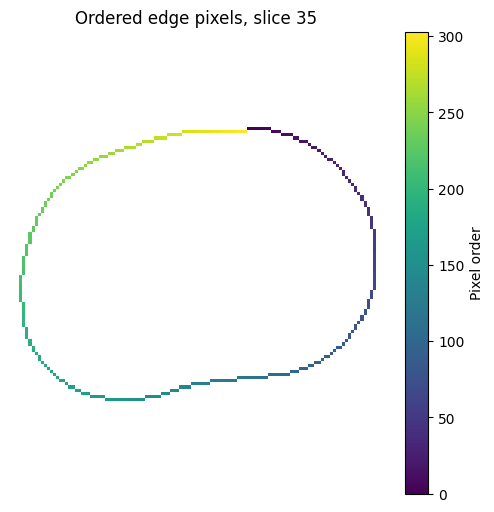

Ordered pixels: 304
Total edge pixels: 304


In [ ]:
def plot_ordered_pixels_from_instance(ug_instance, slice_idx, pad=3, figsize=(6, 6)):
    import numpy as np
    import matplotlib.pyplot as plt
    from uncertainty_util import extract_bands, order_segmentation_pixels

    seg = ug_instance.mask[slice_idx]
    unc_bin = ug_instance.unc_map_bin[slice_idx]

    seg_edge, unc_inner, unc_outer, _, _ = extract_bands(seg, unc_bin)

    ordered_pixels = order_segmentation_pixels(seg_edge)

    if ordered_pixels is None or len(ordered_pixels) == 0:
        print("No ordered pixels found.")
        return None

    order_map = np.full(seg_edge.shape, np.nan)

    for i, (y, x) in enumerate(ordered_pixels):
        order_map[int(y), int(x)] = i

    ys, xs = np.where(seg_edge)

    y_min, y_max = ys.min(), ys.max()
    x_min, x_max = xs.min(), xs.max()

    y_min = max(0, y_min - pad)
    y_max = min(seg_edge.shape[0], y_max + pad)
    x_min = max(0, x_min - pad)
    x_max = min(seg_edge.shape[1], x_max + pad)

    cropped = order_map[y_min:y_max, x_min:x_max]

    plt.figure(figsize=figsize)
    plt.imshow(cropped, cmap="viridis")
    plt.colorbar(label="Pixel order")
    plt.title(f"Ordered edge pixels, slice {slice_idx}")
    plt.axis("equal")
    plt.axis("off")
    plt.show()

    print("Ordered pixels:", len(ordered_pixels))
    print("Total edge pixels:", np.sum(seg_edge))

    return ordered_pixels, order_map


# Function call requires uncertanty map handler object
from unc_handling import UG_prompter
root = r"C:\Users\20202310\Desktop\MSc scriptie\MSc_Graduation_Project\data\LUNDPROBE\ExtendedSamples\development"
unc_handler = UG_prompter(parentfolder=root,subject_nr=0,volume_of_interest="CTVT",verbose=True)
unc_handler.threshold_uncertainty_map(unc_threshold=0.019496,target_mm=3.0,step_fraction=0.025) #Threshold here is set to 0.019496 which corresponds to 3mm average uncertainty for subject 0
ordered_pixels, order_map = plot_ordered_pixels_from_instance(
    unc_handler,
    slice_idx=35,
)

#### Validation of band thickness quantification via normals + raycasting


Method: local_normal
Expected inner: 3.2 mm
Expected outer: 3.2 mm
Expected total: 6.4 mm

Measured inner median: 3.1000000000000014
Measured outer median: 3.4000000000000017
Measured total median: 6.5000000000000036


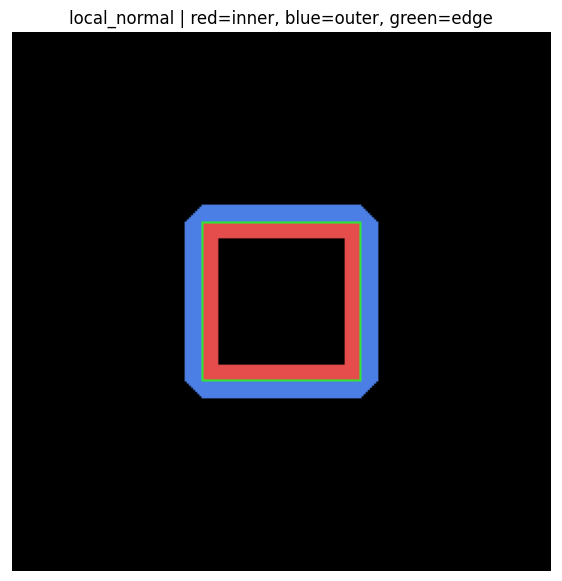


Method: raycast
Expected inner: 3.2 mm
Expected outer: 3.2 mm
Expected total: 6.4 mm

Measured inner median: 3.05
Measured outer median: 3.4000000000000004
Measured total median: 6.4


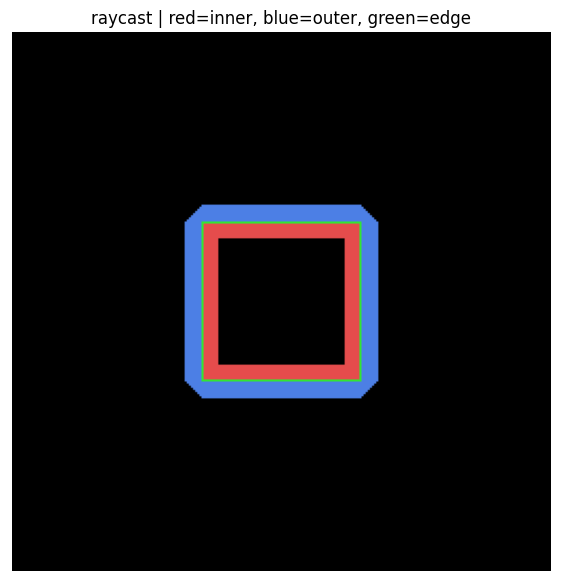

(array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]], shape=(256, 256)),
 array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]], shape=(256, 256)),
 array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_erosion, binary_dilation

from uncertainty_util import (
    extract_bands,
    determine_band_thickness_mm_normals_NEW,
    determine_band_thickness_mm_raycast,
    order_segmentation_pixels,
)


def test_square_uncertainty_band(
    image_shape=(256, 256),
    square_size=76,
    band_px=8,
    pixel_spacing=(0.4, 0.4, 0.4),
    method="local_normal",  # "local_normal" or "raycast"
):
    H, W = image_shape
    cy, cx = H // 2, W // 2
    half = square_size // 2

    y0, y1 = cy - half, cy + half
    x0, x1 = cx - half, cx + half

    # --- segmentation ---
    seg = np.zeros((H, W), dtype=bool)
    seg[y0:y1, x0:x1] = True

    # --- 8 px INNER band ---
    seg_eroded = binary_erosion(seg, iterations=band_px)
    inner_band = seg & ~seg_eroded

    # --- 8 px OUTER band ---
    seg_dilated = binary_dilation(seg, iterations=band_px)
    outer_band = seg_dilated & ~seg

    # --- combined uncertainty ---
    unc_bin = inner_band | outer_band

    # --- extract bands ---
    seg_edge, unc_inner, unc_outer, _, _ = extract_bands(seg, unc_bin)

    # --- compute thickness ---
    if method == "local_normal":
        results = determine_band_thickness_mm_normals_NEW(
            seg=seg,
            unc_inner=unc_inner,
            seg_edge=seg_edge,
            unc_outer=unc_outer,
            ordered_edge_pixels=order_segmentation_pixels(seg_edge),
            interpix_dist=3,
            pixel_interval=1,
            pixel_spacing=pixel_spacing,
        )

        inner_mm = np.asarray(results["inner_mm"])
        outer_mm = np.asarray(results["outer_mm"])

    elif method == "raycast":
        results = determine_band_thickness_mm_raycast(
            seg=seg,
            unc_map=unc_bin,
            unc_inner=unc_inner,
            seg_edge=seg_edge,
            unc_outer=unc_outer,
            pixel_spacing=pixel_spacing,
            angle_step=5,
            step_mm=None,
            pad=5,
        )

        inner_mm = np.asarray(results["inner_mm"])
        outer_mm = np.asarray(results["outer_mm"])

    else:
        raise ValueError("method must be 'local_normal' or 'raycast'")

    total_mm = inner_mm + outer_mm
    valid = total_mm > 0

    # --- expected values ---
    expected = band_px * pixel_spacing[-1]

    print(f"\nMethod: {method}")
    print("Expected inner:", expected, "mm")
    print("Expected outer:", expected, "mm")
    print("Expected total:", 2 * expected, "mm\n")

    if np.sum(valid) == 0:
        print("No valid measurements.")
    else:
        print("Measured inner median:", np.median(inner_mm[valid]))
        print("Measured outer median:", np.median(outer_mm[valid]))
        print("Measured total median:", np.median(total_mm[valid]))

    # --- visualization ---
    plt.figure(figsize=(7, 7))

    overlay = np.zeros((*seg.shape, 3), dtype=float)
    overlay[inner_band] = [0.9, 0.3, 0.3]   # red
    overlay[outer_band] = [0.3, 0.5, 0.9]   # blue
    overlay[seg_edge]   = [0.2, 0.9, 0.2]   # green

    plt.imshow(overlay)
    plt.title(f"{method} | red=inner, blue=outer, green=edge")
    plt.axis("equal")
    plt.axis("off")
    plt.show()

    return seg, unc_bin, seg_edge, unc_inner, unc_outer, results


# --- run tests ---
test_square_uncertainty_band(method="local_normal")
test_square_uncertainty_band(method="raycast")